# Simulator

In [64]:
import numpy as np
import scipy as scp
import pandas as pd
import matplotlib.pyplot as plt

## Definition of System Parameters

### Cost Parameters

In [216]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

### Model Parameters

Define the parameters $\eta = 30000 h$, $\beta = 3$ for the components "Fail Age" given by a Weibull distribution.

Define the parameters $\mu = 5000 h$, $\sigma = 15\% \mu$ for the time between inspections, given by a Normal distribution.

Define the expiration age as $\mu$ for the automatic mandatory component replacement, despite inspections. 

In [201]:
eta = 30*24
beta = 3

expiration = 1.1*eta

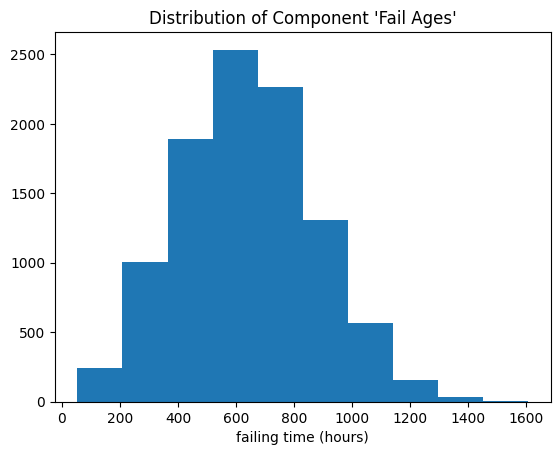

In [67]:
fail_ages = eta*np.random.weibull(beta, size=10000)

plt.hist(fail_ages)
plt.xlabel("failing time (hours)")
plt.title("Distribution of Component 'Fail Ages'")
plt.show()

### Inspection Parameters

In [207]:
mu = 7*24
sigma = 0.15*mu

theta = 12

In [185]:
inspection_threshold = 0.5
inspection_deviation = 0.05 # beta: var = param * mu*(1-mu)

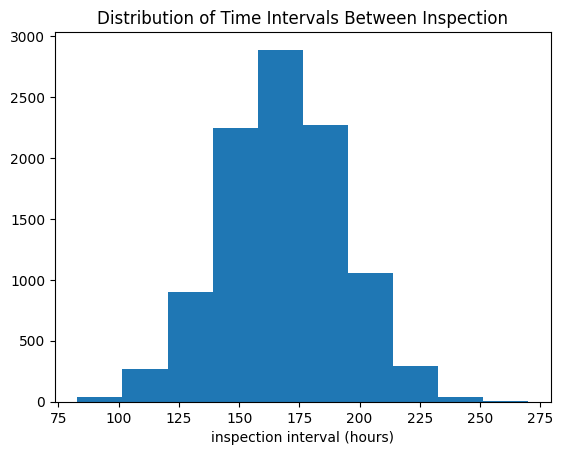

In [70]:
inspection_windows = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.hist(inspection_windows)
plt.xlabel("inspection interval (hours)")
plt.title("Distribution of Time Intervals Between Inspection")
plt.show()

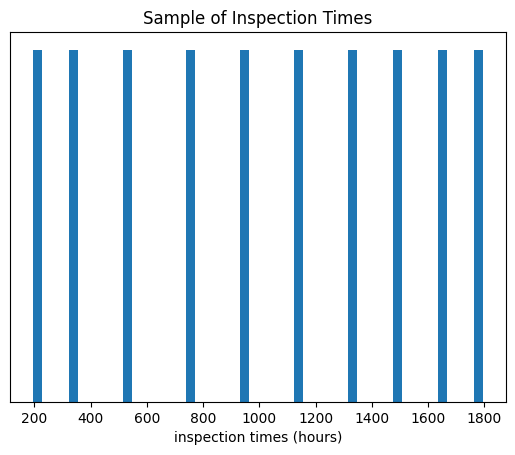

In [71]:
inspection_times = np.cumsum(inspection_windows)[:10]

plt.hist(inspection_times, bins=50)
plt.xlabel("inspection times (hours)")
plt.yticks([])
plt.title("Sample of Inspection Times")
plt.show()

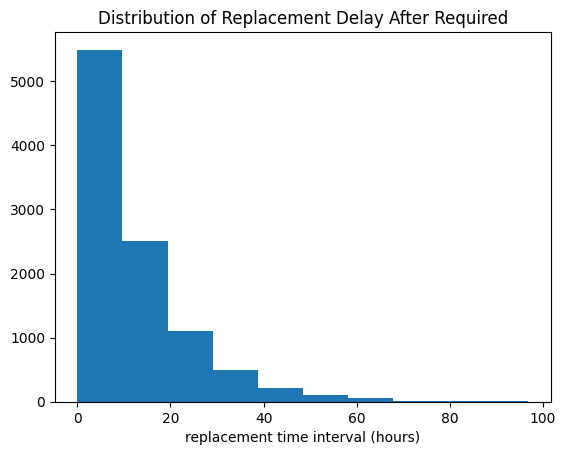

In [210]:
inspection_windows = np.random.exponential(theta, size=10000)

plt.hist(inspection_windows)
plt.xlabel("replacement time interval (hours)")
plt.title("Distribution of Replacement Delay After Required")
plt.show()

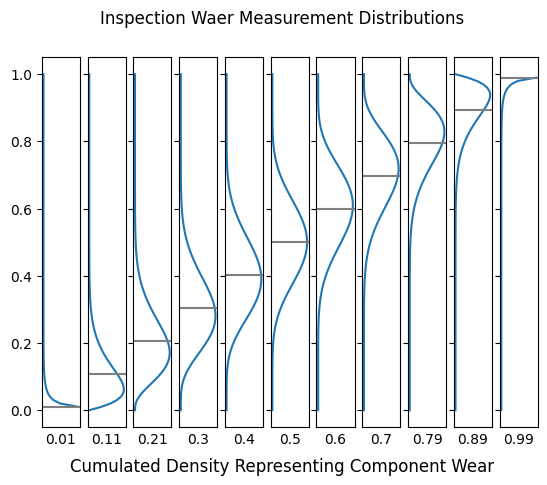

In [72]:
n = 11
fig, ax = plt.subplots(1, n, sharey=True)

cdfs = np.linspace(0.01,0.99,n)

sample = np.linspace(0,1,100)
for i in range(n):
    age_cdf = cdfs[i]

    var = inspection_deviation*age_cdf*(1-age_cdf)
    a = age_cdf * (age_cdf*(1-age_cdf)/var-1)
    b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
    
    pdf = scp.stats.beta.pdf(sample, a, b)

    ax[i].plot(pdf, sample)
    ax[i].axhline(y=age_cdf, color="gray")
    ax[i].set_xlabel(age_cdf.round(2))
    ax[i].set_xticks([])

plt.suptitle("Inspection Waer Measurement Distributions")
fig.supxlabel("Cumulated Density Representing Component Wear")
plt.show()

## Build Simulator

We build the classes and functions responsible for describing the relevant objects (Component, System) and other relevant events, such as inspections and component replacement.

### Objects Component and System

In [133]:
class Component:
    def __init__(self, id_component, expiration, eta, beta):
        self.id = id_component

        # distribution parameters
        self.eta = eta
        self.beta = beta

        # age, expiration amd fail
        self.age = 0
        self.age_expi = expiration
        self.age_fail = eta*np.random.weibull(beta)

In [125]:
class System:
    def __init__(self, id_system, component):
        self.id = id_system
        
        # age and 
        self.age = 0
        # component
        self.component = component
        # cummulated costs
        self.cost_cumulated = 0

In [211]:
class Inspector:
    def __init__(self, deviation, threshold):
        self.deviation = deviation
        self.threshold = threshold
    
    def component_cdf(self, component):
        age = component.age
        eta = component.eta
        beta = component.beta

        age_cdf = scp.stats.weibull_min.cdf(age/eta, beta)

        return age_cdf
    
    def inspect(self, component):
        # exact cdf
        age_cdf = self.component_cdf(component)

        # adds imprecision by sampling from a Beta
        var = self.deviation*age_cdf*(1-age_cdf)
        a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
        b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
        age_beta = np.random.beta(a,b)

        # conditional report
        replace = age_beta > self.threshold

        return replace
    
    def inspect_ff(self, component):
        # exact cdf
        age_cdf = self.component_cdf(component)
        replace = age_cdf > self.threshold

        return replace
    
    def schedule_next(self, time_last_inspection, mu, sigma):
        time_next_inspection = time_last_inspection
        time_next_inspection += np.random.normal(mu, sigma)

        return time_next_inspection
    
    def schedule_replacement(self, time_last_event, theta, urgent=False):
        time_replacement = time_last_event
        time_replacement += 0 if urgent else np.random.exponential(theta)

        return time_replacement


In [254]:
class Manager:
    def __init__(self, n_systems, system_factory, component_factory, inspector):
        # initialize systems
        self.systems = [next(system_factory) for _ in range(n_systems)]

        # inspector and factory
        self.inspector = inspector
        self.component_factory = component_factory

        # components to be reused
        self.components_reuse = []

        # access to event times
        self.t_last_event = 0
        self.t_last_inspection = {system.id:0 for system in self.systems}
        self.t_next_inspection = {system.id:self.inspector.schedule_next(
            self.t_last_event, mu, sigma) for system in self.systems}
        self.t_plan_replacement = {system.id:np.inf for system in self.systems}
        self.t_last_event_system = {system.id:0 for system in self.systems}


    def next_times(self, system):
        # compute relevant event times
        t_to_fail = system.component.age_fail-system.component.age
        t_to_insp = self.t_next_inspection[system.id]-self.t_last_event
        t_to_repl = self.t_plan_replacement[system.id]-self.t_last_event
        
        # closest event to happen
        t_to_evnt = min(t_to_fail, t_to_insp, t_to_repl)

        # return diferent times
        return t_to_evnt, t_to_fail, t_to_insp, t_to_repl
    

    def schedule_replacement(self, system, urgent=False):
        t_replacement_ = self.inspector.schedule_replacement(
                self.t_last_event, theta, urgent=urgent)
        self.t_plan_replacement[system.id] = t_replacement_


    def replace_component(self, system):
        # save old and get new component
        old_component = system.component
        if len(self.components_reuse) > 0:
            component_reuse = True
            new_component = self.components_reuse.pop(0)
        else:
            component_reuse = False
            new_component = next(self.component_factory)
        
        # replace component
        system.component = new_component

        # save old component if possible
        has_not_expired = old_component.age < old_component.age_expi
        has_not_failled = old_component.age < old_component.age_fail
        ff = None
        if has_not_expired and has_not_failled:
            ff = self.inspector.inspect_ff(old_component)
            if not ff:
                self.components_reuse.append(old_component)
        
        return ff, component_reuse
    

    def next_event_(self, system):
        # compute next relevant event times
        t_to_events = self.next_times(system=system)
        t_to_evnt, t_to_fail, t_to_insp, t_to_repl = t_to_events

        # update all system and component ages
        self.t_last_event += t_to_evnt
        for system_ in self.systems:
            system_.age += t_to_evnt
            system_.component.age += t_to_evnt

        # save info to report before replacement
        component_id = system.component.id
        component_age = system.component.age
        usage_since_last_event_h = self.t_last_event
        usage_since_last_event_h -= self.t_last_event_system[system.id]
        
        # update last event time for system
        self.t_last_event_system[system.id] = self.t_last_event

        # evaluate different event cases
        ff = None
        event_report = None
        if t_to_evnt == t_to_repl:
            event_type = "replacement"
            # replace
            ff, component_reuse = self.replace_component(system)
            
            # compute cost
            event_cost = cost_replacement
            if component_reuse:
                event_report = "reused"
            else:
                event_report = "unused"
                event_cost += cost_component

            # unschedule replacement
            self.t_plan_replacement[system.id] = np.inf

        elif t_to_evnt == t_to_fail:
            event_type = "failure"
            event_cost = cost_failure
            # schedule imediate replacement
            self.schedule_replacement(system, urgent=True)
            
        elif t_to_evnt == t_to_insp:
            event_type = "inspection"
            event_cost = cost_inspection

            # checks expiration date
            if system.component.age >= system.component.age_expi:
                replace = True
                event_report = "expired"
            else:
                # checks wear level
                replace = self.inspector.inspect(system.component)
                if replace:
                    event_report = "wornout"

            # schedule a replacement if necessary
            if replace:
                self.schedule_replacement(system, urgent=False)

            # schedule next inspection
            self.t_last_inspection[system.id] = self.t_last_event
            self.t_next_inspection[system.id] = self.inspector.schedule_next(
                self.t_last_event, mu, sigma)

        else:
            raise Exception("An Unknown Event Type Occurred")

        # update cost
        system.cost_cumulated += event_cost

        # event data
        event_data = {
            'system_id':system.id,
            'component_id':component_id,
            'event_date':self.t_last_event,
            'event_time':None,
            'event_type':event_type,
            'event_report':event_report,
            'system_age':system.age,
            'component_age':component_age,
            'usage_since_last_event_h':usage_since_last_event_h,
            'FF':ff,
            'cost_event':event_cost,
            'cost_cumulated':system.cost_cumulated}

        return event_data
    

    def next_event(self):
        # sort all systems by closest event time
        get_next_event_time = lambda system: self.next_times(system)[0]
        ordered_by_time = sorted(self.systems, key=get_next_event_time)

        # run closest event and return results
        next_event_system = ordered_by_time[0]
        return self.next_event_(next_event_system)

### System and Component Factory

Functionalities responsible for centralizing the creation of new objects with unique IDs

In [255]:
def component_factory(id_0, expiration, eta, beta):
    id_component = id_0
    while True:
        id_component += 1
        yield Component(id_component, expiration, eta, beta)

def system_factory(id_0, component_factory):
    id_system = id_0
    while True:
        id_system += 1
        component = next(component_factory)
        yield System(id_system, component)

In [256]:
def sample_datasets(system_factory, component_factory, inspector,
                    n_systems = 1, n_events = 1000, time_origin=0):
    
    system_data = []

    manager = Manager(n_systems, system_factory, component_factory, inspector)

    # start iterations
    for _ in range(n_events):
        event_data = manager.next_event()
        system_data.append(event_data)

    # create dataframe
    system_df = pd.DataFrame(system_data)
    
    # format dates and times
    system_df.event_date = pd.to_datetime(
        (system_df.event_date*60*60).astype(int), unit='s', origin=time_origin)
    system_df.event_time = system_df.event_date.dt.time
    system_df.event_date = system_df.event_date.dt.date
    system_df.system_age = system_df.system_age.round(2)
    system_df.component_age = system_df.component_age.round(2)
    system_df.usage_since_last_event_h = system_df.usage_since_last_event_h.round(2)

    return system_df

### Simulate

In [257]:
c_factory = component_factory(id_0=0, expiration=expiration, eta=eta, beta=beta)
s_factory = system_factory(id_0=0, component_factory=c_factory)
inspector = Inspector(deviation=inspection_deviation, threshold=inspection_threshold)

In [258]:
df = sample_datasets(s_factory, c_factory, inspector,
                          n_systems = 10, n_events = 10000,
                          time_origin=0)

df

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,6,6,1970-01-06,12:07:19,inspection,None,132.12,132.12,132.12,None,100,100
1,2,2,1970-01-06,22:00:26,inspection,None,142.01,142.01,142.01,None,100,100
2,10,10,1970-01-07,03:00:39,inspection,None,147.01,147.01,147.01,None,100,100
3,4,4,1970-01-07,10:27:19,inspection,None,154.46,154.46,154.46,None,100,100
4,5,5,1970-01-07,18:10:22,inspection,None,162.17,162.17,162.17,None,100,100
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8,1906,1982-10-13,18:21:42,replacement,unused,112050.36,656.44,5.08,True,1100,441100
9996,10,1909,1982-10-13,23:19:19,inspection,None,112055.32,382.32,186.82,None,100,442200
9997,1,1912,1982-10-14,06:12:11,inspection,None,112062.20,198.13,163.37,None,100,447700
9998,6,1908,1982-10-15,19:07:57,inspection,None,112099.13,436.42,181.38,None,100,423700


In [259]:
df.to_csv(f"sample_system_dataset_0.csv")

### Observe the distribution of fail ages

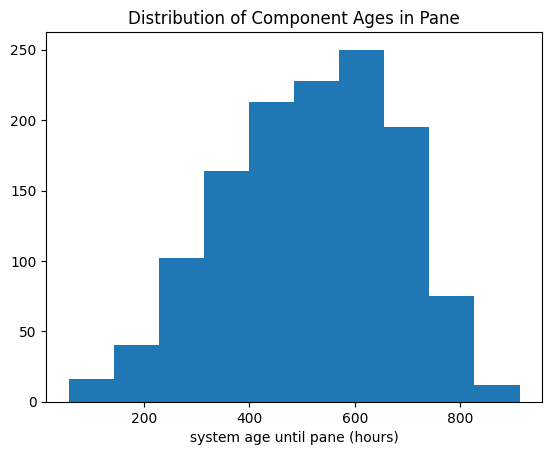

In [261]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

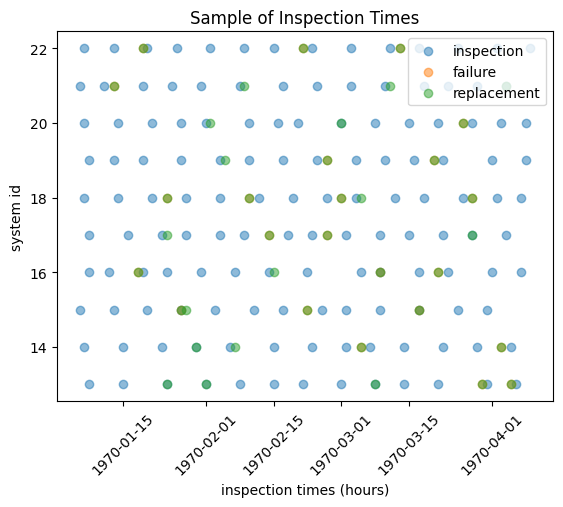

In [250]:
n_events_show = 200
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type,
                alpha=0.5)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.ylabel("system id")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()